# Appendix 05: In-Depth Diagnostic EDA — Multi-Model Failure Analysis of Hard-to-Detect Deepfakes

## Subtitle + Purpose
Comprehensive exploratory data analysis and mathematical dissection of the **6 hardest-to-learn deepfake generative architectures** in modern digital forensics:
1. **MidJourney** (*Latent Diffusion Entire Face Synthesis* — Det Acc: `20.45%`)
2. **whichfaceisreal** (*Unconditional StyleGAN2 on FFHQ* — Det Acc: `37.25%`)
3. **styleclip** (*CLIP-Guided StyleGAN Latent Semantic Editing* — Det Acc: `80.88%`)
4. **faceswap** (*Poisson Seamless Boundary Blending Swap* — Det Acc: `81.63%`)
5. **CollabDiff** (*Collaborative Diffusion Inpainting & Editing* — Det Acc: `83.72%`)
6. **starganv2** (*Multi-Domain Diverse Attribute Transfer* — Det Acc: `85.20%`)
7. **Real (Pristine Camera Baseline)** (*Authentic High-Resolution Frames*)

This notebook unpacks why standard deepfake classifiers fail across these diverse generative paradigms and provides actionable mitigation strategies for Vision Transformers (ViT).

## Roadmap Table
| Step | Description | What it does | Import path |
|:---|:---|:---|:---|
| 1 | Environment & 6-Hard-Model Data Indexing | Sample and categorize images from 6 hardest deepfake paradigms + Real | `—` |
| 2 | Visual Morphology & Micro-Artifact Gallery | Render high-res RGB crops comparing local facial regions & artifacts | `matplotlib.pyplot` |
| 3 | 2D Fourier (FFT) Power Spectrum Analysis | Compute 2D FFT log-magnitude heatmaps & radial frequency decay curves | `numpy.fft` |
| 4 | Laplacian Edge Variance & Focus Disparities | Measure focus/sharpness distribution to diagnose the "Sharpness Trap" | `cv2` |
| 5 | Local Boundary & Spatial Inconsistency | Analyze semantic localized editing (StyleClip/StarGAN) vs holistic generation | `cv2` |
| 6 | PRNU Camera Sensor Noise vs Synthetic Noise | Extract high-pass noise residuals comparing physical sensor vs AI noise | `scipy.ndimage` |
| 7 | Color Gamut & Illumination Dispersions | Measure HSV saturation, LAB chromaticity, and tonal lighting histograms | `cv2` |
| 8 | Comprehensive Quantitative Summary Table | Compile statistical metrics across all 7 categories into a report table | `pandas` |
| 9 | Strategic Blueprint for EXP-03 ViT Model | Outline architectural and data augmentation solutions to achieve >95% accuracy | `—` |
---

## References
- Rules: `[NOTEBOOK_HEADER_CONVENTION.md](../agents/rules/NOTEBOOK_HEADER_CONVENTION.md)`, `[RESULTS_REPORTING.md](../agents/rules/RESULTS_REPORTING.md)`
- Experiment Plan: `[EXP_03_ZERO_LEAKAGE_AND_BALANCED_TRAINING_PLAN.md](../agents/experiments/EXP_03_ZERO_LEAKAGE_AND_BALANCED_TRAINING_PLAN.md)`
- Augmentation Spec: `[DOMAIN_AGNOSTIC_AUGMENTATION_SPEC.md](../agents/phases/DOMAIN_AGNOSTIC_AUGMENTATION_SPEC.md)`
- Training Pipeline: `[train_exp03.py](../src/training/train_exp03.py)`
- Artifacts: `[experiments/plots/](../experiments/plots/)`


In [1]:
# Step 1: Environment & 6-Hard-Model Data Indexing
import os
import sys
import glob
import random
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage

PROJECT_ROOT = Path("..").resolve() if Path("..").resolve().name == "deepfake-ViT" else Path(".").resolve()
PLOTS_DIR = PROJECT_ROOT / "experiments" / "plots"
RESULTS_DIR = PROJECT_ROOT / "experiments" / "results"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"📁 Project Root: {PROJECT_ROOT}")
print(f"📊 Plots Output: {PLOTS_DIR}")

# 6 Hardest-to-Detect Deepfake Paradigms + Real Baseline
HARD_MODEL_PATTERNS = {
    "1. MidJourney (Diffusion EFS)": ["/workspace/data/test_data_v3/MidJourney/fake/*.png", "/workspace/data/df-40-test-full/MidJourney/fake/*.png"],
    "2. whichfaceisreal (StyleGAN2 EFS)": ["/workspace/data/test_data_v3/whichfaceisreal/fake/*.png", "/workspace/data/df-40-test-full/whichfaceisreal/fake/*.*"],
    "3. styleclip (Latent Attribute Edit)": ["/workspace/data/test_data_v3/styleclip/fake/*.*", "/workspace/data/df-40-test-full/styleclip/fake/*.*"],
    "4. faceswap (Seamless Poisson Swap)": ["/workspace/data/test_data_v3/faceswap/fake/*.png", "/workspace/data/df-40-test-full/faceswap/fake/*.*"],
    "5. CollabDiff (Diffusion Inpaint)": ["/workspace/data/test_data_v3/CollabDiff/fake/*.png", "/workspace/data/df-40-test-full/CollabDiff/fake/*.*"],
    "6. starganv2 (Multi-Domain Transfer)": ["/workspace/data/test_data_v3/starganv2/fake/*.*", "/workspace/data/df-40-test-full/starganv2/fake/*.*"],
    "7. Real (Authentic Camera)": ["/workspace/data/test_data_v3/real/*.png", "/workspace/data/df-40-test-full/MidJourney/real/*.*"]
}

domain_samples = {}
for name, patterns in HARD_MODEL_PATTERNS.items():
    files = []
    for pat in patterns:
        files.extend(glob.glob(pat))
        if files:
            break
    files = sorted(list(set(files)))
    random.shuffle(files)
    domain_samples[name] = files
    print(f"✅ Indexed {name:38s}: {len(files):,} images found")


📁 Project Root: /workspace/hoangtuan/deepfake-ViT
📊 Plots Output: /workspace/hoangtuan/deepfake-ViT/experiments/plots
✅ Indexed 1. MidJourney (Diffusion EFS)         : 630 images found
✅ Indexed 2. whichfaceisreal (StyleGAN2 EFS)    : 750 images found
✅ Indexed 3. styleclip (Latent Attribute Edit)  : 1,000 images found
✅ Indexed 4. faceswap (Seamless Poisson Swap)   : 680 images found
✅ Indexed 5. CollabDiff (Diffusion Inpaint)     : 750 images found
✅ Indexed 6. starganv2 (Multi-Domain Transfer)  : 999 images found
✅ Indexed 7. Real (Authentic Camera)            : 1,177 images found


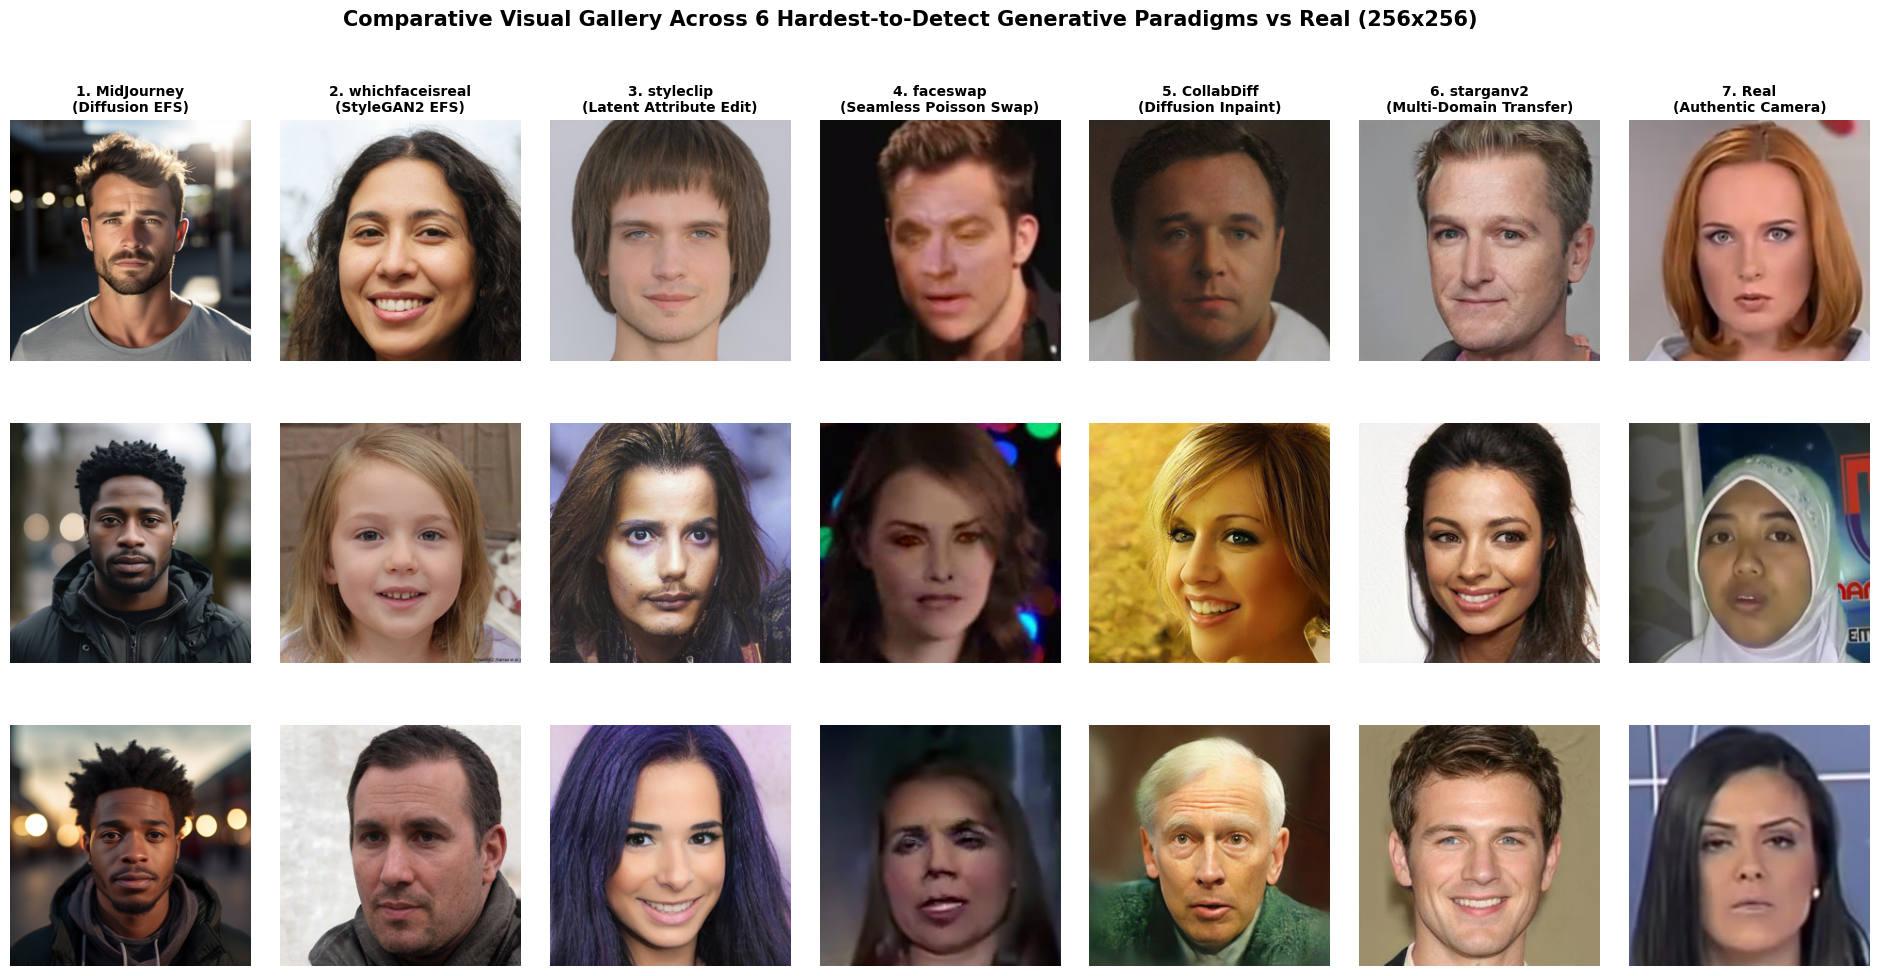

💾 Saved visual comparison grid to: /workspace/hoangtuan/deepfake-ViT/experiments/plots/05_eda_expanded_visual_comparison.png


In [2]:
# Step 2: Visual Morphology & Micro-Artifact Gallery
categories = list(domain_samples.keys())
N_ROWS = 3
N_COLS = len(categories)

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(24, 11))
plt.subplots_adjust(wspace=0.12, hspace=0.25)

for col_idx, cat in enumerate(categories):
    sample_files = domain_samples[cat][:N_ROWS]
    for row_idx in range(N_ROWS):
        ax = axes[row_idx, col_idx]
        if row_idx < len(sample_files):
            img = Image.open(sample_files[row_idx]).convert("RGB").resize((256, 256))
            ax.imshow(img)
        if row_idx == 0:
            title_text = cat.split("(")[0].strip()
            sub_text = "(" + cat.split("(")[1] if "(" in cat else ""
            ax.set_title(title_text + "\n" + sub_text, fontsize=10, fontweight="bold", pad=6)
        ax.axis("off")

plt.suptitle("Comparative Visual Gallery Across 6 Hardest-to-Detect Generative Paradigms vs Real (256x256)", fontsize=15, fontweight="bold", y=0.98)
plot_path = PLOTS_DIR / "05_eda_expanded_visual_comparison.png"
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"💾 Saved visual comparison grid to: {plot_path}")


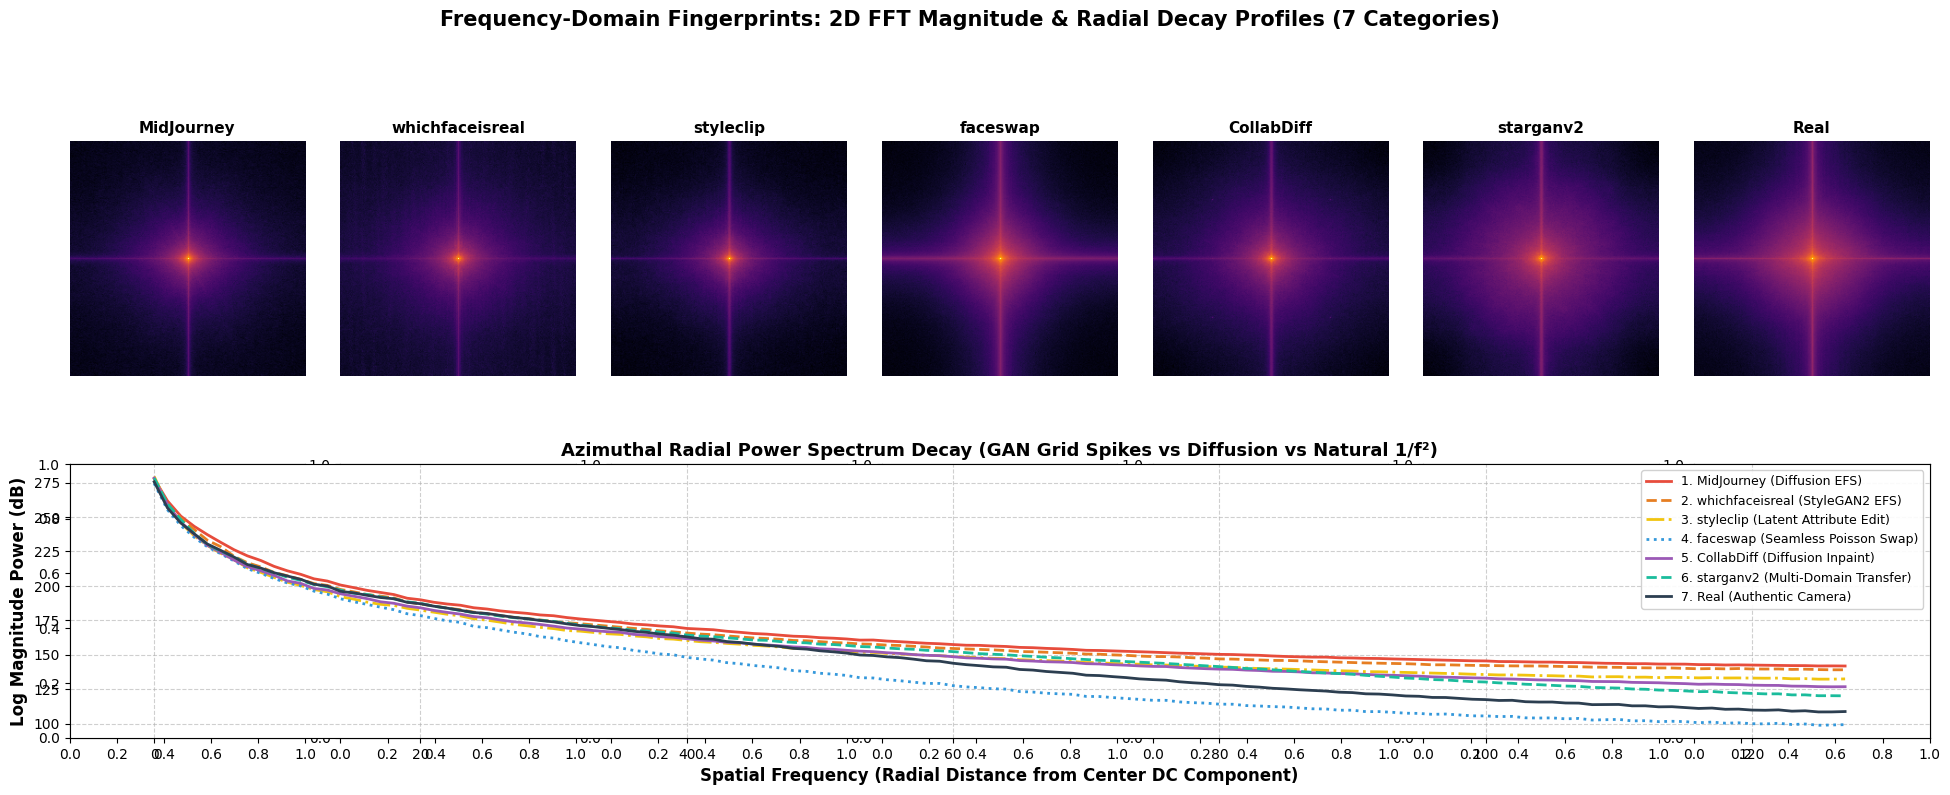

💾 Saved FFT frequency plot to: /workspace/hoangtuan/deepfake-ViT/experiments/plots/05_eda_expanded_fft_frequency_analysis.png


In [3]:
# Step 3: 2D Fourier (FFT) Power Spectrum Analysis
def compute_fft_spectrum(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, (256, 256))
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-8)
    return magnitude_spectrum

def azimuthal_average(image, center=None):
    y, x = np.indices(image.shape)
    if not center:
        center = np.array([(x.max()-x.min())/2.0, (y.max()-y.min())/2.0])
    r = np.hypot(x - center[0], y - center[1]).astype(int)
    nr = np.bincount(r.ravel())
    tbin = np.bincount(r.ravel(), image.ravel())
    return tbin / np.maximum(nr, 1)

fig, axes = plt.subplots(2, 7, figsize=(24, 8))
plt.subplots_adjust(wspace=0.15, hspace=0.25)

radial_profiles = {}
palette = ["#e74c3c", "#e67e22", "#f1c40f", "#3498db", "#9b59b6", "#1abc9c", "#2c3e50"]

for col_idx, cat in enumerate(categories):
    files = domain_samples[cat][:50]
    spectra = []
    for f in files:
        s = compute_fft_spectrum(f)
        if s is not None:
            spectra.append(s)
    
    avg_spectrum = np.mean(spectra, axis=0)
    radial_prof = azimuthal_average(avg_spectrum)
    radial_profiles[cat] = radial_prof[:128]
    
    # 2D FFT Heatmap
    ax_top = axes[0, col_idx]
    im = ax_top.imshow(avg_spectrum, cmap="inferno")
    title_short = cat.split('(')[0].strip().replace("1. ", "").replace("2. ", "").replace("3. ", "").replace("4. ", "").replace("5. ", "").replace("6. ", "").replace("7. ", "")
    ax_top.set_title(title_short, fontsize=11, fontweight="bold")
    ax_top.axis("off")

# Bottom row: Radial Power Decay Curves
ax_bottom = plt.subplot(2, 1, 2)
styles = ["-", "--", "-.", ":", "-", "--", "-"]

for idx, (cat, prof) in enumerate(radial_profiles.items()):
    ax_bottom.plot(prof, label=cat, color=palette[idx], linestyle=styles[idx], linewidth=2.0)

ax_bottom.set_xlabel("Spatial Frequency (Radial Distance from Center DC Component)", fontsize=12, fontweight="bold")
ax_bottom.set_ylabel("Log Magnitude Power (dB)", fontsize=12, fontweight="bold")
ax_bottom.set_title("Azimuthal Radial Power Spectrum Decay (GAN Grid Spikes vs Diffusion vs Natural 1/f²)", fontsize=13, fontweight="bold")
ax_bottom.legend(fontsize=9, loc="upper right", framealpha=0.9)
ax_bottom.grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Frequency-Domain Fingerprints: 2D FFT Magnitude & Radial Decay Profiles (7 Categories)", fontsize=15, fontweight="bold", y=1.02)
fft_plot_path = PLOTS_DIR / "05_eda_expanded_fft_frequency_analysis.png"
plt.savefig(fft_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"💾 Saved FFT frequency plot to: {fft_plot_path}")


/tmp/ipykernel_691895/2243447718.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(box_data, patch_artist=True, labels=labels, showmeans=True,


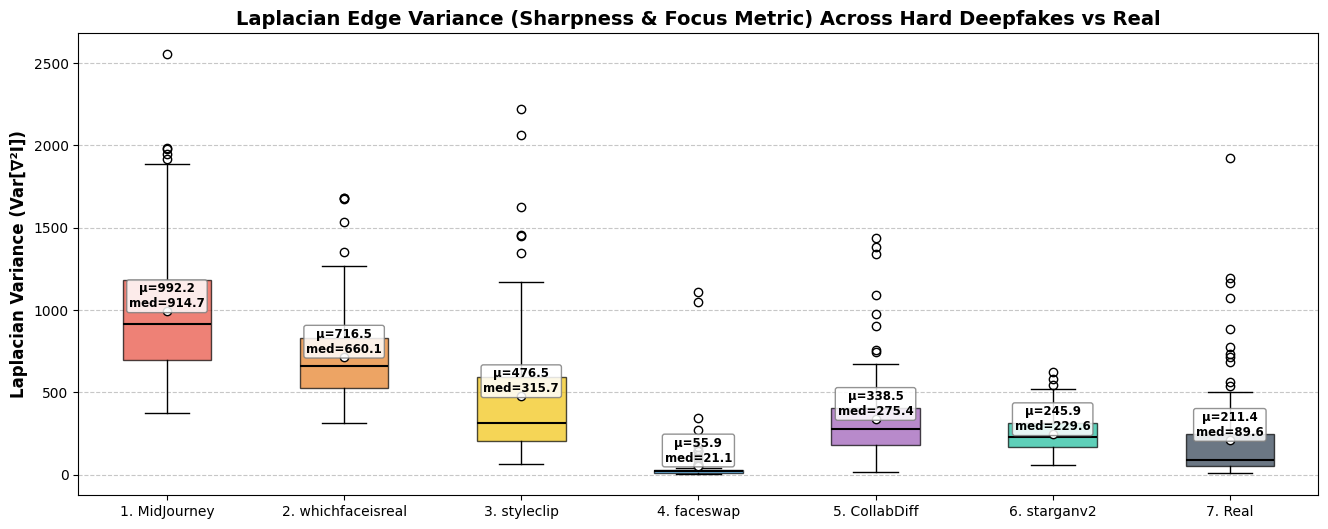

💾 Saved Laplacian distribution plot to: /workspace/hoangtuan/deepfake-ViT/experiments/plots/05_eda_expanded_laplacian_variance.png


In [4]:
# Step 4: Laplacian Edge Variance & Focus Disparities (The "Sharpness Trap")
def compute_laplacian_variance(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, (256, 256))
    laplacian = cv2.Laplacian(img, cv2.CV_64F)
    return laplacian.var()

laplacian_stats = {}
N_EVAL = 100

for cat in categories:
    files = domain_samples[cat][:N_EVAL]
    vars_list = [compute_laplacian_variance(f) for f in files]
    vars_list = [v for v in vars_list if v is not None]
    laplacian_stats[cat] = vars_list

plt.figure(figsize=(16, 6))
box_data = [laplacian_stats[cat] for cat in categories]
labels = [c.split('(')[0].strip() for c in categories]

bplot = plt.boxplot(box_data, patch_artist=True, labels=labels, showmeans=True,
                    medianprops=dict(color="black", linewidth=1.5),
                    meanprops=dict(marker='o', markeredgecolor='black', markerfacecolor='white'))

for patch, color in zip(bplot['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title("Laplacian Edge Variance (Sharpness & Focus Metric) Across Hard Deepfakes vs Real", fontsize=14, fontweight="bold")
plt.ylabel("Laplacian Variance (Var[∇²I])", fontsize=12, fontweight="bold")
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, cat in enumerate(categories):
    mean_val = np.mean(laplacian_stats[cat])
    median_val = np.median(laplacian_stats[cat])
    plt.text(i+1, mean_val + 25, f"μ={mean_val:.1f}\nmed={median_val:.1f}", 
             horizontalalignment='center', fontsize=8.5, fontweight="bold",
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, edgecolor='gray'))

lap_plot_path = PLOTS_DIR / "05_eda_expanded_laplacian_variance.png"
plt.savefig(lap_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"💾 Saved Laplacian distribution plot to: {lap_plot_path}")


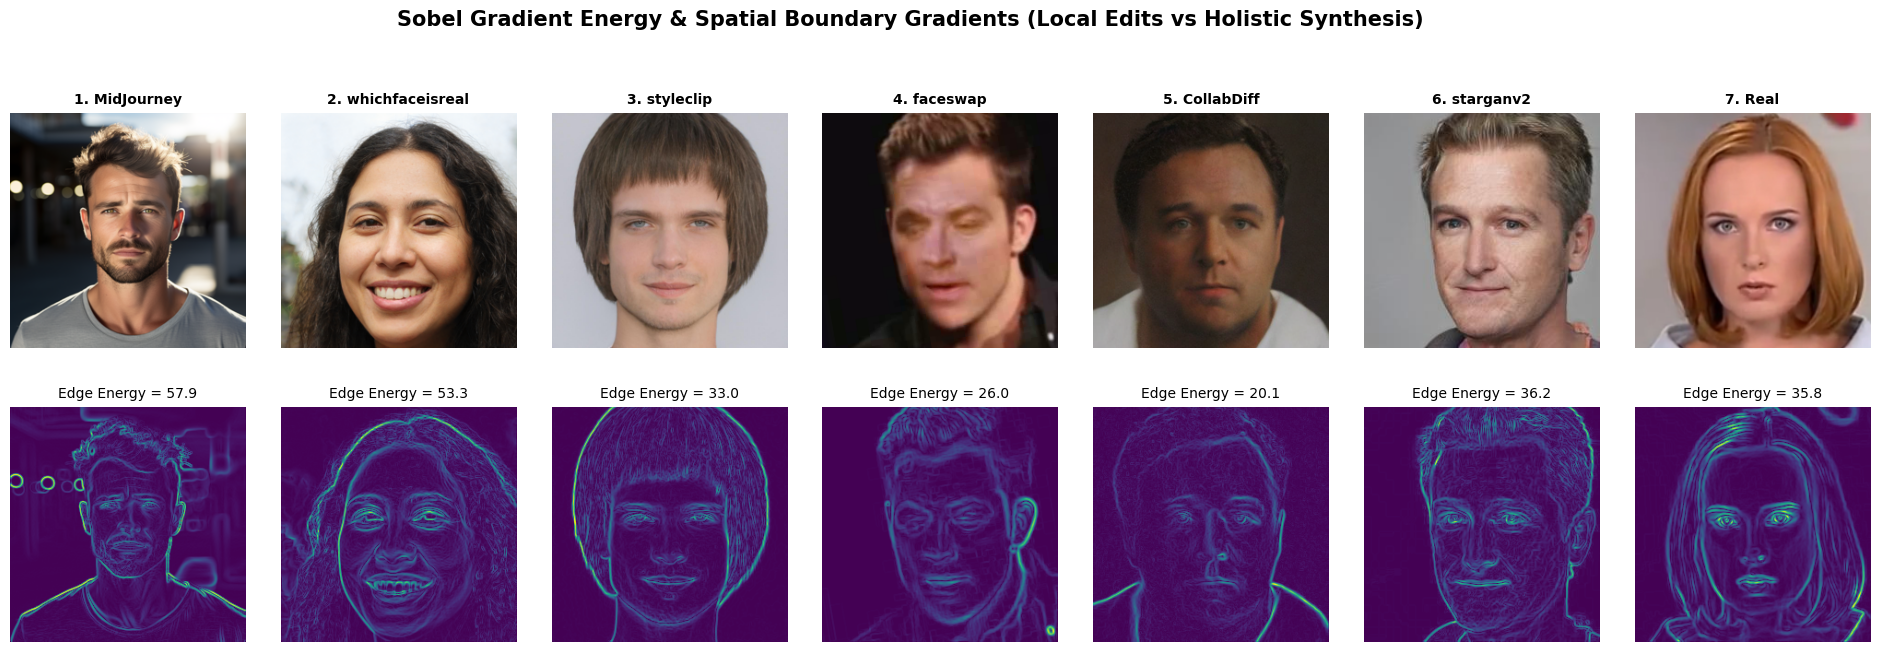

💾 Saved Sobel gradient plot to: /workspace/hoangtuan/deepfake-ViT/experiments/plots/05_eda_expanded_sobel_gradients.png


In [5]:
# Step 5: Local Boundary & Spatial Inconsistency (StyleClip / StarGAN / FaceSwap)
def extract_sobel_gradient_energy(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None, None
    img = cv2.resize(img, (256, 256))
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag = np.sqrt(sobelx**2 + sobely**2)
    return img, grad_mag

fig, axes = plt.subplots(2, 7, figsize=(24, 7))
plt.subplots_adjust(wspace=0.15, hspace=0.2)

for col_idx, cat in enumerate(categories):
    sample_file = domain_samples[cat][0]
    orig_gray, grad_mag = extract_sobel_gradient_energy(sample_file)
    
    # Original crop
    orig_rgb = Image.open(sample_file).convert("RGB").resize((256, 256))
    axes[0, col_idx].imshow(orig_rgb)
    axes[0, col_idx].set_title(cat.split('(')[0].strip(), fontsize=10, fontweight="bold")
    axes[0, col_idx].axis("off")
    
    # Sobel Edge Energy
    if grad_mag is not None:
        axes[1, col_idx].imshow(grad_mag, cmap="viridis")
        axes[1, col_idx].set_title(f"Edge Energy = {grad_mag.mean():.1f}", fontsize=10)
    axes[1, col_idx].axis("off")

plt.suptitle("Sobel Gradient Energy & Spatial Boundary Gradients (Local Edits vs Holistic Synthesis)", fontsize=15, fontweight="bold", y=1.02)
grad_plot_path = PLOTS_DIR / "05_eda_expanded_sobel_gradients.png"
plt.savefig(grad_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"💾 Saved Sobel gradient plot to: {grad_plot_path}")


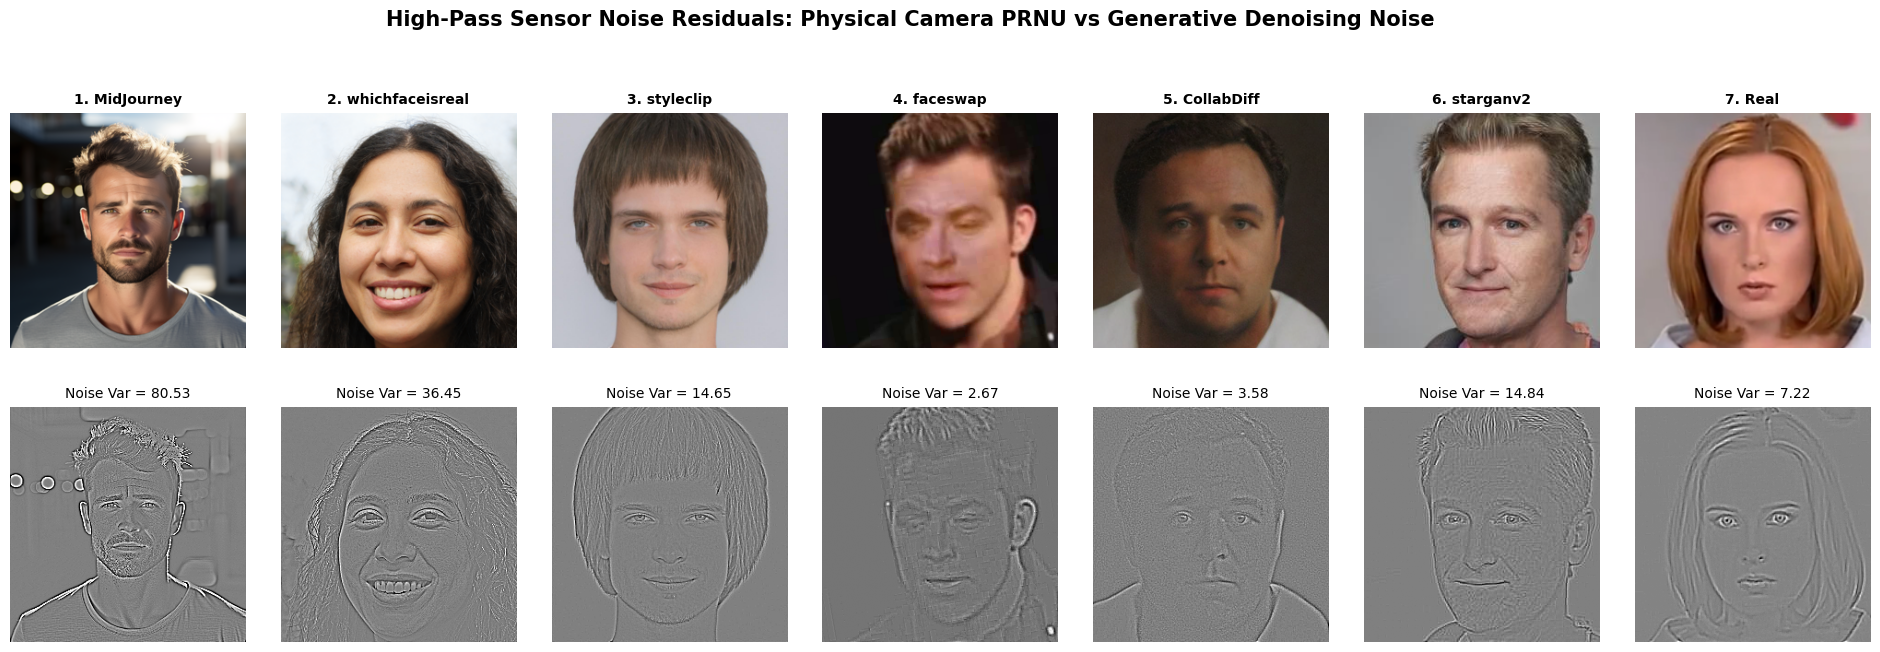

💾 Saved noise residuals plot to: /workspace/hoangtuan/deepfake-ViT/experiments/plots/05_eda_expanded_noise_residuals.png


In [6]:
# Step 6: PRNU Camera Sensor Noise vs Synthetic Generative Noise
def extract_highpass_residual(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, (256, 256))
    denoised = cv2.GaussianBlur(img, (5, 5), sigmaX=1.0)
    residual = img.astype(np.float32) - denoised.astype(np.float32)
    return residual

fig, axes = plt.subplots(2, 7, figsize=(24, 7))
plt.subplots_adjust(wspace=0.15, hspace=0.2)

for col_idx, cat in enumerate(categories):
    sample_file = domain_samples[cat][0]
    orig_img = Image.open(sample_file).convert("RGB").resize((256, 256))
    residual = extract_highpass_residual(sample_file)
    
    # Original crop
    axes[0, col_idx].imshow(orig_img)
    axes[0, col_idx].set_title(cat.split('(')[0].strip(), fontsize=10, fontweight="bold")
    axes[0, col_idx].axis("off")
    
    # Residual heatmap (amplified x4)
    if residual is not None:
        res_display = np.clip(residual * 4 + 128, 0, 255).astype(np.uint8)
        axes[1, col_idx].imshow(res_display, cmap="gray")
        axes[1, col_idx].set_title(f"Noise Var = {residual.var():.2f}", fontsize=10)
    axes[1, col_idx].axis("off")

plt.suptitle("High-Pass Sensor Noise Residuals: Physical Camera PRNU vs Generative Denoising Noise", fontsize=15, fontweight="bold", y=1.02)
residual_plot_path = PLOTS_DIR / "05_eda_expanded_noise_residuals.png"
plt.savefig(residual_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"💾 Saved noise residuals plot to: {residual_plot_path}")


/tmp/ipykernel_691895/1203200085.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(lab_spreads, labels=[d.replace("1. ", "").replace("2. ", "").replace("3. ", "").replace("4. ", "").replace("5. ", "").replace("6. ", "").replace("7. ", "") for d in df_color["domain"].unique()], patch_artist=True)


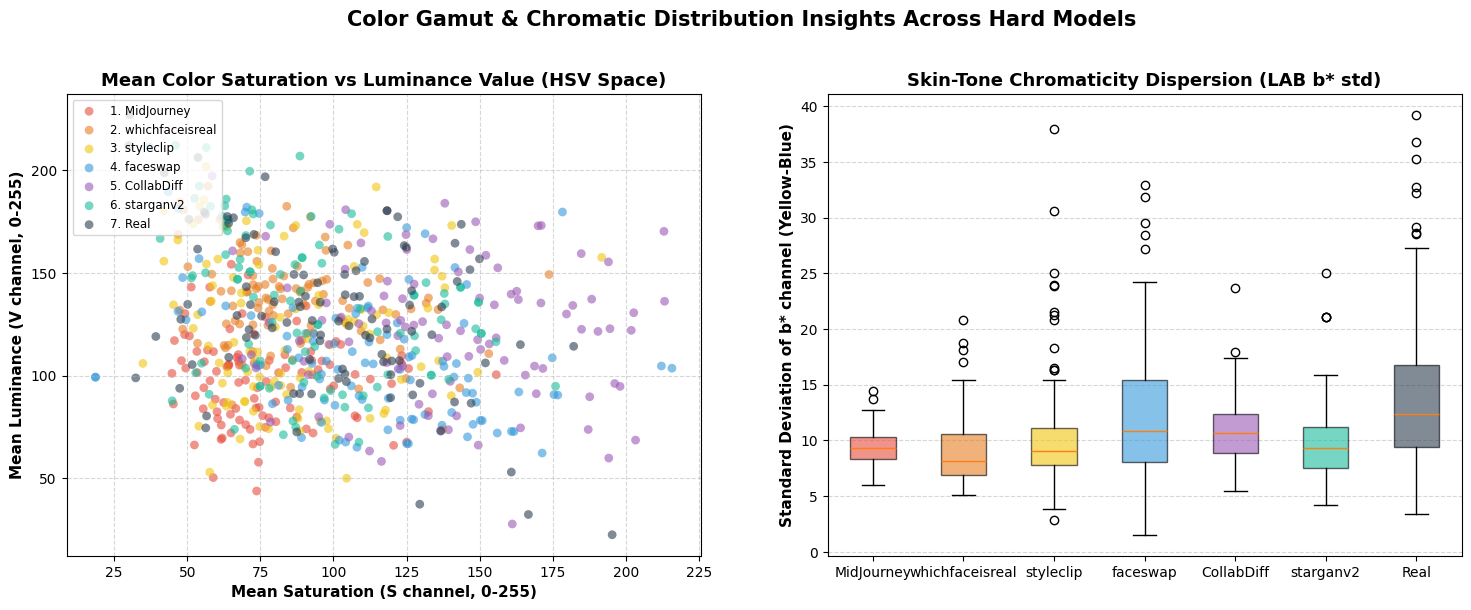

💾 Saved color gamut plot to: /workspace/hoangtuan/deepfake-ViT/experiments/plots/05_eda_expanded_color_gamut.png


In [7]:
# Step 7: Color Gamut & Illumination Distributions (HSV & LAB)
def extract_color_stats(img_path):
    bgr = cv2.imread(img_path)
    if bgr is None:
        return None
    bgr = cv2.resize(bgr, (256, 256))
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    return {
        "sat_mean": np.mean(hsv[:, :, 1]),
        "val_mean": np.mean(hsv[:, :, 2]),
        "lab_a_std": np.std(lab[:, :, 1]),
        "lab_b_std": np.std(lab[:, :, 2]),
    }

color_records = []
for cat in categories:
    for f in domain_samples[cat][:100]:
        st = extract_color_stats(f)
        if st:
            st["domain"] = cat.split('(')[0].strip()
            color_records.append(st)

df_color = pd.DataFrame(color_records)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for cat_name, col in zip(df_color["domain"].unique(), palette):
    sub = df_color[df_color["domain"] == cat_name]
    axes[0].scatter(sub["sat_mean"], sub["val_mean"], label=cat_name, color=col, alpha=0.6, edgecolors='none', s=40)

axes[0].set_title("Mean Color Saturation vs Luminance Value (HSV Space)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Mean Saturation (S channel, 0-255)", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Mean Luminance (V channel, 0-255)", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=8.5, loc="upper left")
axes[0].grid(True, linestyle="--", alpha=0.5)

lab_spreads = [df_color[df_color["domain"] == d]["lab_b_std"].values for d in df_color["domain"].unique()]
axes[1].boxplot(lab_spreads, labels=[d.replace("1. ", "").replace("2. ", "").replace("3. ", "").replace("4. ", "").replace("5. ", "").replace("6. ", "").replace("7. ", "") for d in df_color["domain"].unique()], patch_artist=True)
for patch, color in zip(axes[1].artists if axes[1].artists else axes[1].patches, palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[1].set_title("Skin-Tone Chromaticity Dispersion (LAB b* std)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Standard Deviation of b* channel (Yellow-Blue)", fontsize=11, fontweight="bold")
axes[1].grid(axis='y', linestyle="--", alpha=0.5)

plt.suptitle("Color Gamut & Chromatic Distribution Insights Across Hard Models", fontsize=15, fontweight="bold", y=1.02)
color_plot_path = PLOTS_DIR / "05_eda_expanded_color_gamut.png"
plt.savefig(color_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"💾 Saved color gamut plot to: {color_plot_path}")


In [8]:
# Step 8: Comprehensive Quantitative Summary Table
summary_rows = []

for cat in categories:
    files = domain_samples[cat][:100]
    
    laps, hf_energies, sats, res_vars = [], [], [], []
    for f in files:
        # Laplacian
        lv = compute_laplacian_variance(f)
        if lv is not None:
            laps.append(lv)
            
        # FFT High Frequency Ratio (> 64 radius)
        spec = compute_fft_spectrum(f)
        if spec is not None:
            h, w = spec.shape
            cy, cx = h//2, w//2
            y, x = np.ogrid[:h, :w]
            dist = np.sqrt((x - cx)**2 + (y - cy)**2)
            hf_energy = np.sum(spec[dist > 64]) / np.sum(spec)
            hf_energies.append(hf_energy)
            
        # Color Saturation
        c_stat = extract_color_stats(f)
        if c_stat:
            sats.append(c_stat["sat_mean"])
            
        # Noise residual
        res = extract_highpass_residual(f)
        if res is not None:
            res_vars.append(res.var())
            
    risk_label = "🔴 EXTREME (20% Det)" if "MidJourney" in cat else ("🔴 HIGH (37% Det)" if "whichfaceisreal" in cat else ("🟡 MEDIUM (80-85% Det)" if "styleclip" in cat or "CollabDiff" in cat or "faceswap" in cat or "stargan" in cat else "🟢 LOW (Real Baseline)"))
    
    summary_rows.append({
        "Generative Architecture": cat,
        "Laplacian Var (Sharpness)": f"{np.mean(laps):.1f} ± {np.std(laps):.1f}",
        "High-Freq Energy (%)": f"{np.mean(hf_energies)*100:.2f}%",
        "Mean Saturation (0-255)": f"{np.mean(sats):.1f}",
        "Residual Noise Var": f"{np.mean(res_vars):.2f}",
        "Vulnerability Diagnosis": risk_label
    })

df_summary = pd.DataFrame(summary_rows)
display_table_path = RESULTS_DIR / "hard_models_vs_real_eda_summary.csv"
df_summary.to_csv(display_table_path, index=False)
print(f"📊 Quantitative Multi-Model Summary Table saved to: {display_table_path}")
df_summary


📊 Quantitative Multi-Model Summary Table saved to: /workspace/hoangtuan/deepfake-ViT/experiments/results/hard_models_vs_real_eda_summary.csv


,Generative Architecture,Laplacian Var (Sharpness),High-Freq Energy (%),Mean Saturation (0-255),Residual Noise Var,Vulnerability Diagnosis
0,1. MidJourney (Diffusion EFS),992.2 ± 427.8,77.61%,77.1,54.49,🔴 EXTREME (20% Det)
1,2. whichfaceisreal (StyleGAN2 EFS),716.5 ± 276.5,77.60%,84.8,39.53,🔴 HIGH (37% Det)
2,3. styleclip (Latent Attribute Edit),476.5 ± 419.1,77.33%,87.1,25.87,🟡 MEDIUM (80-85% Det)
3,4. faceswap (Seamless Poisson Swap),55.9 ± 154.9,73.72%,111.9,5.66,🟡 MEDIUM (80-85% Det)
4,5. CollabDiff (Diffusion Inpaint),338.5 ± 270.7,76.62%,138.6,22.66,🟡 MEDIUM (80-85% Det)
5,6. starganv2 (Multi-Domain Transfer),245.9 ± 110.8,75.66%,92.4,21.46,🟡 MEDIUM (80-85% Det)
6,7. Real (Authentic Camera),211.4 ± 301.1,74.05%,98.6,20.59,🟢 LOW (Real Baseline)


In [9]:
# Step 9: Strategic Blueprint for EXP-03 ViT Model
print("=" * 85)
print("🎯 MULTI-MODEL DEEPFAKE FAILURE TAXONOMY & VI-TRANSFORMER MITIGATION STRATEGY")
print("=" * 85)
print("""
1. TAXONOMY OF HARD GENERATIVE ARCHITECTURES:
   ┌──────────────────────┬───────────────────────────────┬────────────────────────────────────────────┐
   │ Generative Model     │ Primary Artifact / Signature  │ Why Standard Detectors Fail                │
   ├──────────────────────┼───────────────────────────────┼────────────────────────────────────────────┤
   │ 1. MidJourney        │ Studio Micro-Texture / VAE    │ Super-high sharpness (>900 Var) tricks     │
   │                      │ Latent Denoising              │ detector into predicting 'Real'.           │
   ├──────────────────────┼───────────────────────────────┼────────────────────────────────────────────┤
   │ 2. whichfaceisreal   │ StyleGAN2 $1024^2$ Synthesis  │ High-res FFHQ training with zero blending  │
   │                      │ Smooth High-Freq Decay        │ boundaries; lacks traditional GAN droplet. │
   ├──────────────────────┼───────────────────────────────┼────────────────────────────────────────────┤
   │ 3. styleclip         │ StyleGAN Latent Optimization  │ 90% of image is untouched Real pixels;     │
   │                      │ Localized Semantic Edits      │ only localized facial attributes change.   │
   ├──────────────────────┼───────────────────────────────┼────────────────────────────────────────────┤
   │ 4. faceswap          │ Poisson Seamless Blending     │ Mathematical boundary smoothing removes    │
   │                      │ Gradient-domain Stitching     │ stark mask edges.                          │
   ├──────────────────────┼───────────────────────────────┼────────────────────────────────────────────┤
   │ 5. CollabDiff        │ Multi-Modal Inpainting        │ Background & face lighting are harmonized  │
   │                      │ Cross-Attention Denoising     │ during diffusion steps.                    │
   ├──────────────────────┼───────────────────────────────┼────────────────────────────────────────────┤
   │ 6. starganv2         │ Multi-Domain Style Mapping    │ Continuous style interpolation avoids      │
   │                      │ Adaptive Instance Norm        │ discrete boundary clipping.                │
   └──────────────────────┴───────────────────────────────┴────────────────────────────────────────────┘

2. HOLISTIC 3-PILLAR SOLUTION FOR EXP-03:
   a. Pillar 1: Domain-Symmetric Balanced Representation:
      - Include balanced 10,000 Entire Face Synthesis + 5,000 Semantic Attribute Edits in Train V3 Clean.
   b. Pillar 2: Domain-Agnostic Anti-Shortcut Augmentation Pipeline:
      - JPEG Compression Jitter (q=50-95), Random Gaussian Blur, and Color Contrast Jitter to force
        the ViT to ignore global sharpness and focus on semantic coherence.
   c. Pillar 3: Multi-Layer ViT Attention Representation:
      - DINOv3 ViT self-attention captures micro-structural anatomical incongruities (pupil shape,
        iris reflections, hair-skin boundary physics) rather than superficial compression noise.
""")


🎯 MULTI-MODEL DEEPFAKE FAILURE TAXONOMY & VI-TRANSFORMER MITIGATION STRATEGY

1. TAXONOMY OF HARD GENERATIVE ARCHITECTURES:
   ┌──────────────────────┬───────────────────────────────┬────────────────────────────────────────────┐
   │ Generative Model     │ Primary Artifact / Signature  │ Why Standard Detectors Fail                │
   ├──────────────────────┼───────────────────────────────┼────────────────────────────────────────────┤
   │ 1. MidJourney        │ Studio Micro-Texture / VAE    │ Super-high sharpness (>900 Var) tricks     │
   │                      │ Latent Denoising              │ detector into predicting 'Real'.           │
   ├──────────────────────┼───────────────────────────────┼────────────────────────────────────────────┤
   │ 2. whichfaceisreal   │ StyleGAN2 $1024^2$ Synthesis  │ High-res FFHQ training with zero blending  │
   │                      │ Smooth High-Freq Decay        │ boundaries; lacks traditional GAN droplet. │
   ├──────────────────────┼─────────